In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

import joblib
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Feature Engineered Data
df = pd.read_csv("../transaction_data.csv")

print("Data Shape:", df.shape)
print("\nTarget Distribution:")
print(df["isFraud"].value_counts())
print("\nFraud Percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)

display(df.head())

Data Shape: (6362620, 31)

Target Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,is_oldbalanceOrg_zero,...,amount_to_oldbalance_dest_ratio,sender_account_emptied,dest_received_large_amount,is_large_transaction,step_bucket,transactions_in_step,is_high_velocity_step,is_dest_high_balance,type_risk_score,suspicious_signal_count
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,3,0,...,0.000000,0,0,0,0,2708,0,0,1,1
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,3,0,...,0.000000,0,0,0,0,2708,0,0,1,1
2,1,181.00,181.0,0.00,0.0,0.0,1,0,4,0,...,0.000000,1,0,0,0,2708,0,0,3,2
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,1,0,...,0.008545,1,0,0,0,2708,0,0,3,2
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,3,0,...,0.000000,0,0,0,0,2708,0,0,1,1


In [3]:
# Drop target and irrelevant columns
drop_cols = ["isFraud", "isFlaggedFraud"]

X = df.drop(columns=drop_cols)
y = df["isFraud"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFeature Columns:")
print(list(X.columns))

Feature Matrix Shape: (6362620, 29)
Target Shape: (6362620,)

Feature Columns:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_encoded', 'is_oldbalanceOrg_zero', 'is_newbalanceOrig_zero', 'is_oldbalanceDest_zero', 'is_newbalanceDest_zero', 'log_amount', 'balance_change_orig', 'expected_balance_change_orig', 'balance_error_orig', 'balance_change_dest', 'expected_balance_change_dest', 'balance_error_dest', 'amount_to_oldbalance_orig_ratio', 'amount_to_oldbalance_dest_ratio', 'sender_account_emptied', 'dest_received_large_amount', 'is_large_transaction', 'step_bucket', 'transactions_in_step', 'is_high_velocity_step', 'is_dest_high_balance', 'type_risk_score', 'suspicious_signal_count']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Important for imbalanced data
)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTest Target Distribution:")
print(y_test.value_counts())

Training Set Shape: (5090096, 29)
Test Set Shape: (1272524, 29)

Training Target Distribution:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Test Target Distribution:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


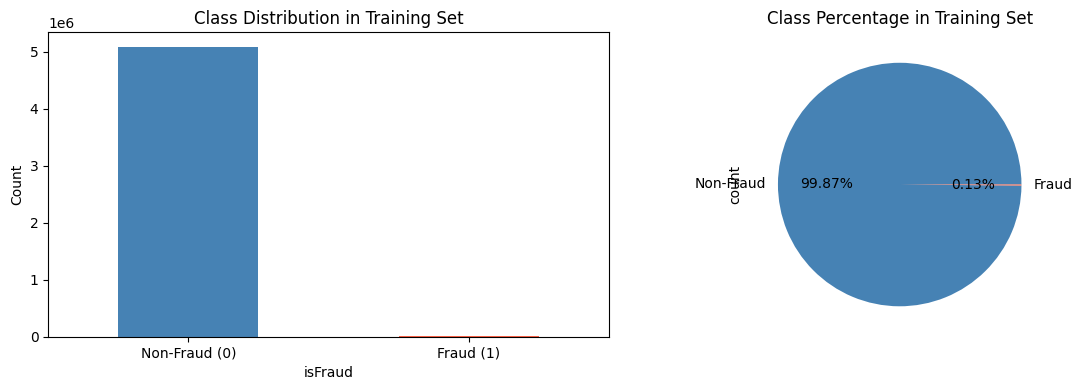


Class Imbalance Ratio: 1 fraud for every 774 non-fraud transactions


In [5]:
# Class Imbalance - Understand the Problem

# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
y_train.value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "tomato"]
)
axes[0].set_title("Class Distribution in Training Set")
axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Percentage pie chart
y_train.value_counts().plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.2f%%",
    labels=["Non-Fraud", "Fraud"],
    colors=["steelblue", "tomato"]
)
axes[1].set_title("Class Percentage in Training Set")

plt.tight_layout()
plt.show()

print(f"\nClass Imbalance Ratio: 1 fraud for every {round(y_train.value_counts()[0] / y_train.value_counts()[1])} non-fraud transactions")

In [6]:
import numpy as np

# (Optional but recommended) memory reduce: float32
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

# Keep all fraud, sample non-fraud
NEG_POS_RATIO = 30  # start with 30; if RAM low, try 20. If RAM ok, try 50.

fraud_idx = y_train[y_train == 1].index
nonfraud_idx = y_train[y_train == 0].index

n_fraud = len(fraud_idx)
n_nonfraud_needed = min(len(nonfraud_idx), n_fraud * NEG_POS_RATIO)

np.random.seed(42)
nonfraud_sample_idx = np.random.choice(nonfraud_idx, size=n_nonfraud_needed, replace=False)

selected_idx = np.concatenate([fraud_idx, nonfraud_sample_idx])

X_train_resampled = X_train.loc[selected_idx].copy()
y_train_resampled = y_train.loc[selected_idx].copy()

# Shuffle resampled train set
perm = np.random.permutation(len(selected_idx))
X_train_resampled = X_train_resampled.iloc[perm]
y_train_resampled = y_train_resampled.iloc[perm]

print("Original Train Shape:", X_train.shape)
print("Original Fraud %:", round(y_train.mean() * 100, 4))

print("\nResampled Train Shape:", X_train_resampled.shape)
print("Resampled Fraud %:", round(y_train_resampled.mean() * 100, 4))
print("\nResampled class counts:\n", y_train_resampled.value_counts())

Original Train Shape: (5090096, 29)
Original Fraud %: 0.1291

Resampled Train Shape: (203670, 29)
Resampled Fraud %: 3.2258

Resampled class counts:
 isFraud
0    197100
1      6570
Name: count, dtype: int64


In [8]:
# Helper Evaluation Function 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*70}")
    print(f"Model: {model_name}")
    print(f"{'='*70}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Non-Fraud", "Fraud"]))

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Fraud","Fraud"],
                yticklabels=["Non-Fraud","Fraud"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


Model: Logistic Regression (Undersampled Train)

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.98      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9992
PR-AUC  : 0.9899


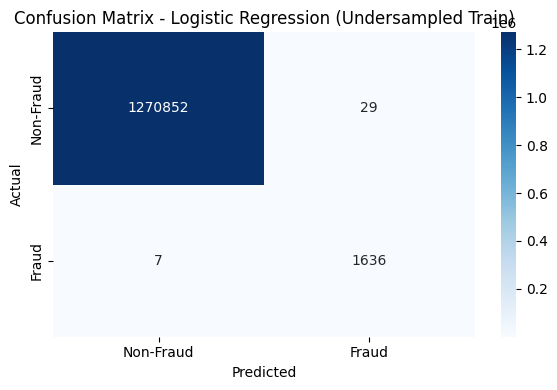

In [9]:
# Model 1 — Logistic Regression (Baseline)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("lr", LogisticRegression(max_iter=2000, random_state=42))
])

lr_model.fit(X_train_resampled, y_train_resampled)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_results = evaluate_model("Logistic Regression (Undersampled Train)", y_test, lr_pred, lr_prob)


Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.99      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9998
PR-AUC  : 0.9987


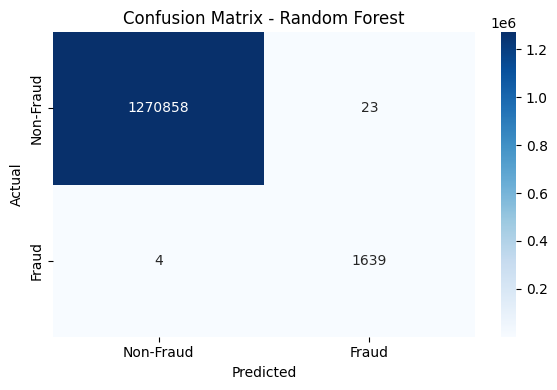

In [10]:
#  Model 2 — Random Forest (balanced_subsample)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.98      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 0.9996
PR-AUC  : 0.9987


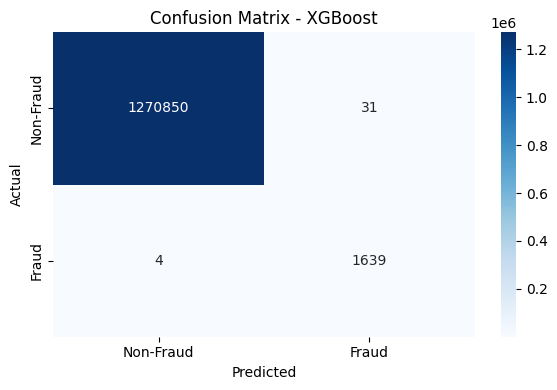

In [11]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",     # memory efficient
    max_bin=256,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train_resampled, y_train_resampled)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

[LightGBM] [Info] Number of positive: 6570, number of negative: 197100
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4101
[LightGBM] [Info] Number of data points in the train set: 203670, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032258 -> initscore=-3.401197
[LightGBM] [Info] Start training from score -3.401197
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

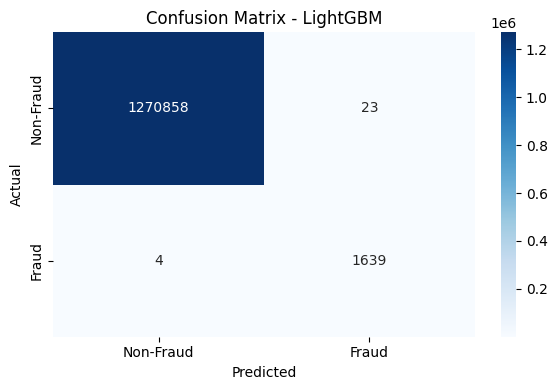

In [12]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train_resampled, y_train_resampled)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

lgb_results = evaluate_model("LightGBM", y_test, lgb_pred, lgb_prob)

In [14]:
# Compare All Models and Select Best Mode"

import pandas as pd

all_results = pd.DataFrame([lr_results, rf_results, xgb_results, lgb_results])
all_results["roc_auc"] = all_results["roc_auc"].round(4)
all_results["pr_auc"]  = all_results["pr_auc"].round(4)

display(all_results.sort_values(["pr_auc", "roc_auc"], ascending=False))

# Select Best Mode

best_model_name = all_results.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0]["model"]
print("Best model selected (by PR-AUC):", best_model_name)

model_map = {
    "Logistic Regression (Undersampled Train)": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model
}

best_model = model_map[best_model_name]
print("Best model object ready.")

,model,roc_auc,pr_auc
1,Random Forest,0.9998,0.9987
3,LightGBM,0.9998,0.9987
2,XGBoost,0.9996,0.9987
0,Logistic Regression (Undersampled Train),0.9992,0.9899


Best model selected (by PR-AUC): Random Forest
Best model object ready.


In [15]:
 # Save Best Model + Store Test Data 

import os
import joblib
import numpy as np

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(best_model, "../models/best_fraud_model.pkl")
print("Saved: ../models/best_fraud_model.pkl")

# Save test set for next notebook
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

# Save probabilities too (best model)
best_prob = best_model.predict_proba(X_test)[:, 1]
np.save("../data/processed/best_model_probs.npy", best_prob)

print("Saved: X_test.csv, y_test.csv, best_model_probs.npy")

Saved: ../models/best_fraud_model.pkl
Saved: X_test.csv, y_test.csv, best_model_probs.npy


In [16]:
# choose Random Forest
print("Best model:", best_model_name)
print("Sample probabilities:", best_prob[:10])
print("Sample predicted labels:", (best_prob >= 0.5).astype(int)[:10])

Best model: Random Forest
Sample probabilities: [9.31628059e-04 6.67077687e-06 2.24201514e-05 2.75191420e-05
 2.33322520e-04 1.08893762e-05 0.00000000e+00 3.04436681e-04
 6.09634069e-06 0.00000000e+00]
Sample predicted labels: [0 0 0 0 0 0 0 0 0 0]
